In [1]:
import numpy as np
from qutip import Qobj, partial_transpose

# Eigenvalue of Density Matrix >= 0
# Peres-Horodecki Criterion method : If no entanglement or, after partial transpose, Eigenvalue of Density Matrix >= 0.
#                                    If has entanglement, after partial transpose, Eigenvalue of Density Matrix < 0.
#                                    It can say this method is to find entanglement or not.


# global parameter
p_val = 0.5

# ------------------------------------------------------------------------

def get_werner_state(p):
    if not (0 <= p <= 1):
        raise ValueError("Parameter p must be between 0 and 1.")

    matrix_elements = np.array([
        [(1 - p) / 4,  0,            0,            0          ],
        [0,            (1 + p) / 4,  -p / 2,       0          ],
        [0,            -p / 2,       (1 + p) / 4,  0          ],
        [0,            0,            0,            (1 - p) / 4]
    ])
    rho = Qobj(matrix_elements, dims=[[2, 2], [2, 2]])
    return rho

# ------------------------------------------------------------------------
# Partial Transpose
rho_AB = get_werner_state(p_val)
print(f"Original Density Matrix (p = {p_val}):")
print(rho_AB)
print("# ------------------------------------------------------------------------")

rho_PT_B = partial_transpose(rho_AB, [0, 1])   # T_B
rho_PT_A = partial_transpose(rho_AB, [1, 0])   # T_A

print(f"\nPartial Transpose A (p = {p_val}):")
print(np.round(rho_PT_A.full().real, 4))
print(f"\nPartial Transpose B (p = {p_val}):")
print(np.round(rho_PT_B.full().real, 4))
print("# ------------------------------------------------------------------------")

# ------------------------------------------------------------------------
# Eigenvalues 
evals = np.sort(np.linalg.eigvalsh(rho_PT_A.full()))
print(f"\nEigenvalues of ρ^{{T_A}}: {np.round(evals, 6)}")
print(f"  λ_min = {evals[0]:.6f}  →  "
      f"{'ENTANGLED (λ < 0)' if evals[0] < -1e-10 else 'SEPARABLE (all λ ≥ 0)'}")
print(f"  Analytical check: (1-3p)/4 = {(1 - 3*p_val)/4:.6f}")

evals = np.sort(np.linalg.eigvalsh(rho_PT_B.full()))
print(f"\nEigenvalues of ρ^{{T_B}}: {np.round(evals, 6)}")
print(f"  λ_min = {evals[0]:.6f}  →  "
      f"{'ENTANGLED (λ < 0)' if evals[0] < -1e-10 else 'SEPARABLE (all λ ≥ 0)'}")
print(f"  Analytical check: (1-3p)/4 = {(1 - 3*p_val)/4:.6f}")

Matplotlib is building the font cache; this may take a moment.


Original Density Matrix (p = 0.5):
Quantum object: dims=[[2, 2], [2, 2]], shape=(4, 4), type='oper', dtype=Dense, isherm=True
Qobj data =
[[ 0.125  0.     0.     0.   ]
 [ 0.     0.375 -0.25   0.   ]
 [ 0.    -0.25   0.375  0.   ]
 [ 0.     0.     0.     0.125]]
# ------------------------------------------------------------------------

Partial Transpose A (p = 0.5):
[[ 0.125  0.     0.    -0.25 ]
 [ 0.     0.375  0.     0.   ]
 [ 0.     0.     0.375  0.   ]
 [-0.25   0.     0.     0.125]]

Partial Transpose B (p = 0.5):
[[ 0.125  0.     0.    -0.25 ]
 [ 0.     0.375  0.     0.   ]
 [ 0.     0.     0.375  0.   ]
 [-0.25   0.     0.     0.125]]
# ------------------------------------------------------------------------

Eigenvalues of ρ^{T_A}: [-0.125  0.375  0.375  0.375]
  λ_min = -0.125000  →  ENTANGLED (λ < 0)
  Analytical check: (1-3p)/4 = -0.125000

Eigenvalues of ρ^{T_B}: [-0.125  0.375  0.375  0.375]
  λ_min = -0.125000  →  ENTANGLED (λ < 0)
  Analytical check: (1-3p)/4 = -0.1250

<>:37: SyntaxWarning: invalid escape sequence '\l'
/tmp/xpython_42/1539854229.py:37: SyntaxWarning: invalid escape sequence '\l'
  plt.axhline(0, color='red', linestyle='--', label="Separability Boundary ($\lambda=0$)")
Matplotlib is building the font cache; this may take a moment.


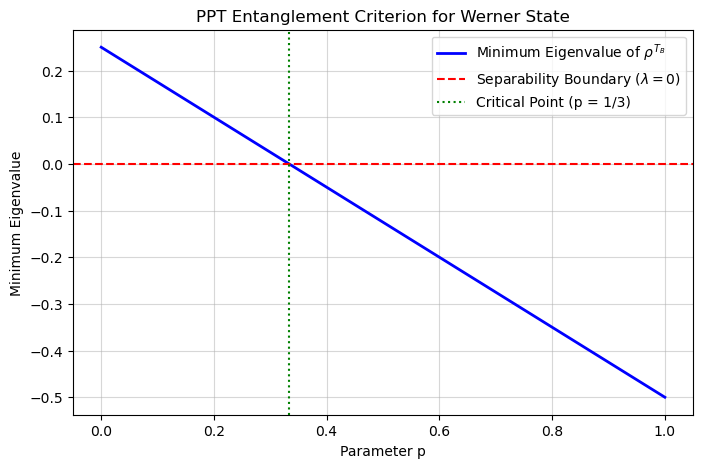

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from qutip import Qobj, partial_transpose

# global parameter
p_val = 0.5

# ------------------------------------------------------------------------

def get_werner_state(p):
    if not (0 <= p <= 1):
        raise ValueError("Parameter p must be between 0 and 1.")

    matrix_elements = np.array([
        [(1 - p) / 4,  0,            0,            0          ],
        [0,            (1 + p) / 4,  -p / 2,       0          ],
        [0,            -p / 2,       (1 + p) / 4,  0          ],
        [0,            0,            0,            (1 - p) / 4]
    ])
    rho = Qobj(matrix_elements, dims=[[2, 2], [2, 2]])
    return rho

# ------------------------------------------------------------------------
p_values = np.linspace(0, 1, 100)
min_evals = []

# calculate all elements
for p in p_values:
    rho = get_werner_state(p)
    rho_PT_B = partial_transpose(rho, [0, 1])
    evals = np.linalg.eigvalsh(rho_PT_B.full())
    min_evals.append(np.min(evals))

# ------------------------------------------------------------------------
plt.figure(figsize=(8, 5))
plt.plot(p_values, min_evals, label="Minimum Eigenvalue of $\\rho^{T_B}$", color='blue', linewidth=2)
plt.axhline(0, color='red', linestyle='--', label="Separability Boundary ($\lambda=0$)")

# pin p = 1/3
plt.axvline(1/3, color='green', linestyle=':', label="Critical Point (p = 1/3)")

plt.xlabel("Parameter p")
plt.ylabel("Minimum Eigenvalue")
plt.title("PPT Entanglement Criterion for Werner State")
plt.legend()
plt.grid(True, alpha=0.5)
plt.show()